# 08 - Capstone: the whole system

**Goal.** Assemble every component into one closed loop and evaluate it as a small
experiment: a controlled ablation across three architectures and four scenarios,
with per-scenario mechanism analysis, multi-seed statistics, a component ablation,
and an honest account of the limitations.

We use `courselib`, the consolidated library that mirrors what notebooks 01-07 built.

## The assembled system

The full closed loop chains every component built in notebooks 01-07: perception feeds
three monitors, their scores fuse into one integrity number, and that number sets the
shared authority and the speed. The block diagram shows the data flow (the numbers in
parentheses are the notebooks).

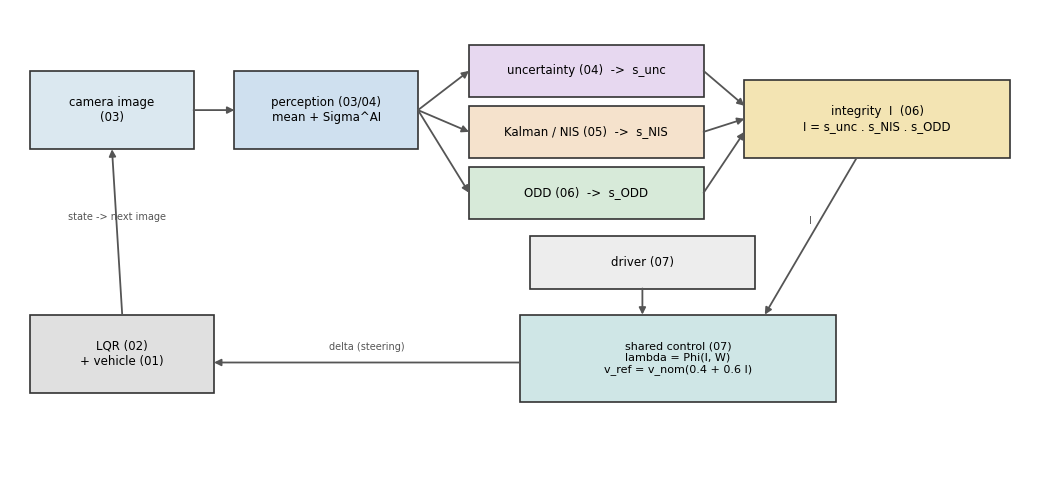

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
fig, ax = plt.subplots(figsize=(10.5, 5.0)); ax.axis("off"); ax.set_xlim(0, 100); ax.set_ylim(0, 54)

def box(x, y, w, h, text, fc, fs=8.5):
    ax.add_patch(Rectangle((x, y), w, h, facecolor=fc, edgecolor="#333", lw=1.2))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fs)

def arrow(x1, y1, x2, y2, text=None, dy=1.4):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#555", lw=1.3, shrinkA=0, shrinkB=0))
    if text: ax.text((x1+x2)/2, (y1+y2)/2 + dy, text, ha="center", fontsize=7, color="#555")

box(2, 38, 16, 9, "camera image\n(03)", "#dbe8f0")
box(22, 38, 18, 9, "perception (03/04)\nmean + Sigma^AI", "#cfe0ef")
box(45, 44, 23, 6, "uncertainty (04)  ->  s_unc", "#e7d8f0")
box(45, 37, 23, 6, "Kalman / NIS (05)  ->  s_NIS", "#f5e2cc")
box(45, 30, 23, 6, "ODD (06)  ->  s_ODD", "#d7ead9")
box(72, 37, 26, 9, "integrity  I  (06)\nI = s_unc . s_NIS . s_ODD", "#f3e4b3")
box(50, 9, 31, 10, "shared control (07)\nlambda = Phi(I, W)\nv_ref = v_nom(0.4 + 0.6 I)", "#cfe6e6", fs=8)
box(51, 22, 22, 6, "driver (07)", "#ededed")
box(2, 10, 18, 9, "LQR (02)\n+ vehicle (01)", "#e0e0e0")

arrow(18, 42.5, 22, 42.5)
for yb in (47, 40, 33):                         # perception -> three monitors
    arrow(40, 42.5, 45, yb)
for yb, yi in ((47, 43), (40, 41.5), (33, 40)): # three monitors -> integrity
    arrow(68, yb, 72, yi)
arrow(83, 37, 74, 19, "I")                      # integrity -> shared control
arrow(62, 22, 62, 19)                           # driver -> shared control (from above)
arrow(50, 13.5, 20, 13.5, "delta (steering)")   # shared control -> plant
arrow(11, 19, 10, 38, "state -> next image")    # plant -> camera (loop)
plt.tight_layout(); plt.show()

Three architectures use this same machinery differently:

- **naive** - perception -> LQR, full automation, no monitoring;
- **hard handover** - switch fully to the driver when the *reported uncertainty*
  $\mathrm{tr}\,\Sigma^{AI}$ crosses a threshold;
- **proposed** - filter the estimate, fuse the integrity score, share authority
  smoothly and contract speed.

## 1. Methodology

**Controlled comparison.** For a given seed the plant, perception noise, driver and
scenario are *identical* across the three methods; only the use of the perception
output differs. Any difference in outcome is therefore attributable to the
monitoring-and-arbitration layer, not to luck.

**Scenarios** map to failure modes: `nominal` (in-domain), `fog` (visible
degradation - blur/darkness/occlusion), `ood_curve` (an out-of-distribution regime
that still looks like a valid image), `conflict` (an overloaded driver fighting the
automation).

**Metrics.** RMSE and max of the lateral error $e_y$; number of lane exits
($|e_y|>0.7$ m); steering jerk ($\sum_k|\Delta\delta_k|$, ride quality);
**unsafe-AI-usage** = fraction of time the automation is trusted ($\lambda>0.5$)
while the vehicle is *outside* the ODD (the safety-critical figure).

**Statistics.** Because the comparison is paired (same seeds), we report the mean
over seeds and put a **bootstrap 95% confidence interval** [1] on the paired
difference between methods; an interval excluding zero is a reliable improvement.

In [2]:
import sys; sys.path.append("..")
import numpy as np
from courselib import (build_scenario, run_episode, metrics, METHODS, SCENARIOS,
                       use_course_style, trust_panel, METHOD_COLORS)
use_course_style()

rows = []
for sc in SCENARIOS:
    fr = build_scenario(sc, T=30.0)
    for m in METHODS:
        me = metrics(run_episode(m, fr, seed=0))
        rows.append((sc, m, me["RMSE_ey"], me["lane_exits"], me["steering_jerk"], me["unsafe_ai_usage_pct"]))
print("%-10s %-9s %7s %6s %8s %9s" % ("scenario", "method", "RMSE", "exits", "jerk", "unsafe%"))
for r in rows:
    print("%-10s %-9s %7.3f %6d %8.2f %9.1f" % r)

scenario   method       RMSE  exits     jerk   unsafe%
nominal    naive       0.035      0    12.10       0.0
nominal    handover    0.035      0    12.10       0.0
nominal    proposed    0.036      0     6.20       0.0
fog        naive       0.245      4    82.08      32.2
fog        handover    0.145      0    15.57       0.0
fog        proposed    0.045      0    10.46       0.0
ood_curve  naive       0.187      0    15.96      33.3
ood_curve  handover    0.187      0    15.96      33.3
ood_curve  proposed    0.052      0    11.14       0.2
conflict   naive       0.035      0    12.10       0.0
conflict   handover    0.035      0    12.10       0.0
conflict   proposed    0.036      0     7.38       0.0


## 2. Mechanism analysis

The aggregate numbers hide *why* each method behaves as it does. Two figures make it
concrete.

**Out-of-distribution curve (the decisive case).** The reported uncertainty barely
moves, so the hard-handover threshold never trips - it is *identical to naive*. The
model-based checks are what react: the NIS spikes and the ODD margin on the
(map-provided) curvature falls, together collapsing the integrity score and shifting
authority.

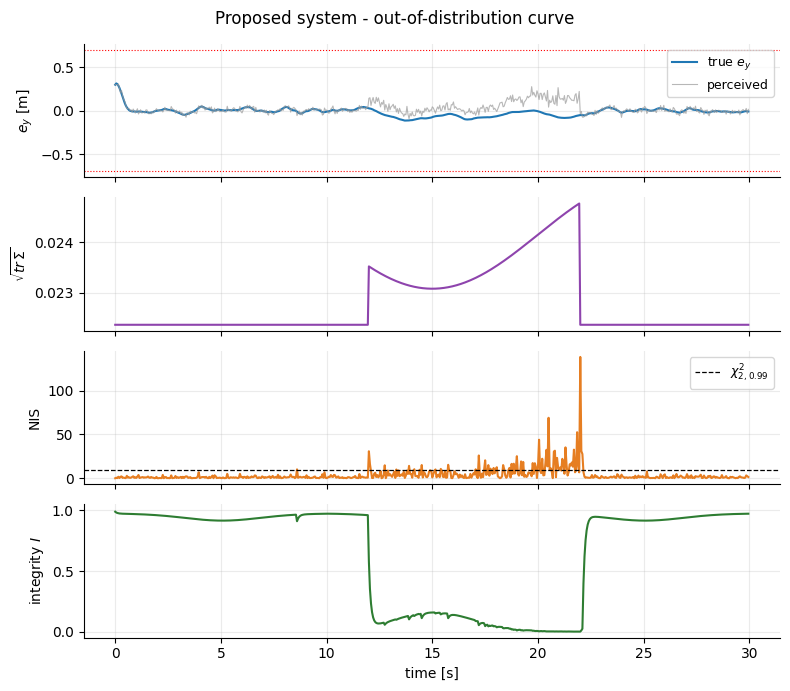

In [3]:
import matplotlib.pyplot as plt
log = run_episode("proposed", build_scenario("ood_curve", T=30.0), seed=0)
trust_panel(log, "Proposed system - out-of-distribution curve"); plt.show()

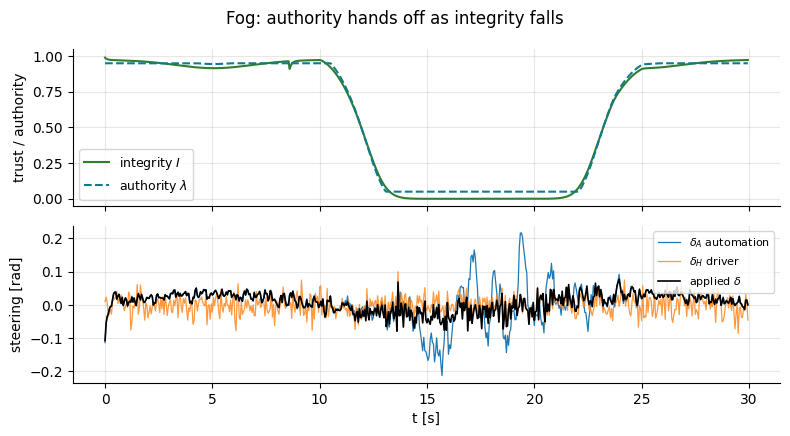

In [4]:
# Fog: the uncertainty rises, integrity falls, and authority hands off smoothly
from courselib import CHI2_2DOF
log = run_episode("proposed", build_scenario("fog", T=30.0), seed=0)
t = log["t"]
fig, ax = plt.subplots(2, 1, figsize=(8, 4.4), sharex=True)
ax[0].plot(t, log["integrity"], color=METHOD_COLORS["proposed"], label="integrity $I$")
ax[0].plot(t, log["lambda"], color="#0e7c8b", ls="--", label="authority $\\lambda$")
ax[0].set_ylabel("trust / authority"); ax[0].legend(loc="lower left"); ax[0].set_ylim(-.05, 1.05)
ax[1].plot(t, log["delta_auto"], label="$\\delta_A$ automation", lw=.9)
ax[1].plot(t, log["delta_human"], label="$\\delta_H$ driver", lw=.9, alpha=.8)
ax[1].plot(t, log["delta"], 'k', lw=1.2, label="applied $\\delta$")
ax[1].set_ylabel("steering [rad]"); ax[1].set_xlabel("t [s]"); ax[1].legend(loc="upper right", fontsize=8)
for a in ax: a.grid(alpha=.3)
fig.suptitle("Fog: authority hands off as integrity falls"); plt.tight_layout(); plt.show()

In `fog` the perception uncertainty genuinely rises, so integrity falls and authority
transfers to the driver *smoothly* while the automation's noisy command is
de-weighted. In `conflict`, by contrast, perception is fine, so integrity stays high,
authority stays with the automation, and the overloaded/mistaken driver is correctly
out-voted (notebook 07). Different mechanism, same principle: authority follows
integrity.

## 3. Is the improvement statistically real?

One seed could be a fluke. We repeat every method on 20 seeds per scenario, report
the mean RMSE, and bootstrap a 95% confidence interval on the *paired* difference
(proposed minus baseline), aggregated over the two degraded scenarios where it should
matter.

In [5]:
seeds = range(20)
rmse = {m: {sc: [] for sc in SCENARIOS} for m in METHODS}
unsafe = {m: {sc: [] for sc in SCENARIOS} for m in METHODS}
for sc in SCENARIOS:
    for s in seeds:
        fr = build_scenario(sc, T=30.0)
        for m in METHODS:
            me = metrics(run_episode(m, fr, seed=s))
            rmse[m][sc].append(me["RMSE_ey"]); unsafe[m][sc].append(me["unsafe_ai_usage_pct"])

print("mean RMSE e_y (+/- std) over 20 seeds")
print("%-10s %14s %14s %14s" % ("scenario", "naive", "handover", "proposed"))
for sc in SCENARIOS:
    cells = []
    for m in METHODS:
        a = np.array(rmse[m][sc]); cells.append("%.3f+/-%.3f" % (a.mean(), a.std()))
    print("%-10s %14s %14s %14s" % (sc, *cells))

def boot_ci(d, n=20000, seed=0):
    r = np.random.default_rng(seed); idx = r.integers(0, len(d), (n, len(d)))
    m = d[idx].mean(1); return d.mean(), np.percentile(m, 2.5), np.percentile(m, 97.5)

deg = ["fog", "ood_curve"]
d_naive = np.array([rmse["proposed"][sc][i] - rmse["naive"][sc][i]    for sc in deg for i in range(len(seeds))])
d_hand  = np.array([rmse["proposed"][sc][i] - rmse["handover"][sc][i] for sc in deg for i in range(len(seeds))])
for name, d in [("proposed - naive", d_naive), ("proposed - handover", d_hand)]:
    m, lo, hi = boot_ci(d)
    sig = "significant" if hi < 0 else "not significant"
    print("\n%-20s  mean dRMSE = %+.3f m   95%% CI [%+.3f, %+.3f]  -> %s" % (name, m, lo, hi, sig))

mean RMSE e_y (+/- std) over 20 seeds
scenario            naive       handover       proposed
nominal     0.034+/-0.001  0.034+/-0.001  0.035+/-0.001
fog         0.242+/-0.049  0.170+/-0.019  0.043+/-0.003
ood_curve   0.193+/-0.004  0.193+/-0.004  0.052+/-0.006
conflict    0.034+/-0.001  0.034+/-0.001  0.036+/-0.001

proposed - naive      mean dRMSE = -0.170 m   95% CI [-0.185, -0.157]  -> significant

proposed - handover   mean dRMSE = -0.134 m   95% CI [-0.139, -0.129]  -> significant


## 4. Component ablation: what is each part doing?

To show that the integrity score's parts *earn their place*, we rebuild the closed
loop directly from the library with switches, and turn components off one at a time.
The test bed is the out-of-distribution curve, where the failure is subtle.

In [6]:
from courselib import (Vehicle, VehicleParams, LQRController, SharedController,
                       SharedControlParams, SyntheticPerception, KalmanMonitor,
                       ODD, IntegrityMonitor, SimulatedDriver)

def run_cfg(frames, use_nis=True, use_odd=True, filt=True, speed=True, seed=0):
    vp = VehicleParams(); veh = Vehicle(vp, x0=(0.3, 0.02))
    per = SyntheticPerception(seed=seed); lqr = LQRController(veh)
    shared = SharedController(SharedControlParams(v_nom=vp.v)); drv = SimulatedDriver(seed=seed+1)
    odd = ODD(); integ = IntegrityMonitor(odd)
    A, B, E = veh.linear_model(); kf = KalmanMonitor(A, B, E, np.diag([1e-4, 1e-4]), P0=np.diag([0.05, 0.02]))
    kf.x = np.array([0.3, 0.02]); prev = 0.0
    ey, lam_log, out = [], [], []
    for fr in frames:
        true = veh.x.copy()
        po = per.measure(true, fr.kappa, fr.cond); y, R = po["mean"], po["cov"]
        kf.predict(prev, fr.kappa); nis = kf.update(y, R)
        nis_u = nis if use_nis else 0.0
        b, bl, oc = (fr.cond.brightness, fr.cond.blur, fr.cond.occlusion) if use_odd else (1.0, 0.0, 0.0)
        kap = fr.kappa if use_odd else 0.0
        I, _ = integ.update(po["trace"], nis_u, kap, b, bl, oc)
        xhat = kf.x.copy() if filt else y
        vcmd = shared.reference_speed(I) if speed else vp.v
        ff = lqr.feedforward(fr.kappa); fb = lqr.feedback(xhat, v=vcmd)
        dh = drv.command(true, fr.workload, fr.available, fr.conflict)
        delta, lam, vref = shared.arbitrate(fb, dh, ff, I, fr.workload, fr.available)
        if not speed: vref = vp.v                          # no contraction: hold the nominal speed
        delta = float(np.clip(delta, -vp.delta_max, vp.delta_max))
        veh.step(delta, fr.kappa, v=vref); prev = delta
        ey.append(true[0]); lam_log.append(lam)
        out.append(odd.inside(fr.kappa, fr.cond.brightness, fr.cond.blur, fr.cond.occlusion))
    ey = np.array(ey); lam_log = np.array(lam_log); inside = np.array(out)
    return {"RMSE": float(np.sqrt(np.mean(ey**2))),
            "unsafe%": 100*float(np.mean((lam_log > 0.5) & ~inside))}

fr = build_scenario("ood_curve", T=30.0)
configs = [("full proposed",              dict()),
           ("no speed contraction",       dict(speed=False)),
           ("no NIS (ODD still on)",      dict(use_nis=False)),
           ("no ODD (NIS still on)",      dict(use_odd=False)),
           ("uncertainty only (no NIS+ODD)", dict(use_nis=False, use_odd=False))]
print("%-30s %8s %9s" % ("configuration", "RMSE", "unsafe%"))
for name, kw in configs:
    r = run_cfg(fr, **kw); print("%-30s %8.3f %9.1f" % (name, r["RMSE"], r["unsafe%"]))

configuration                      RMSE   unsafe%
full proposed                     0.052       0.2
no speed contraction              0.070       0.2


no NIS (ODD still on)             0.053       0.2
no ODD (NIS still on)             0.170      30.2
uncertainty only (no NIS+ODD)     0.192      33.3


The ablation is precise about each part. Removing the **speed contraction** detects
nothing less - it shrinks the operating envelope, it does not *detect* anything - but
it costs tracking: at a constant 15 m/s the RMSE rises from 0.052 to 0.070 m here (by
half on average over ten seeds), and the bend's lateral acceleration rises from 0.42 g
to 1.08 g, which a kinematic plant does not penalise (section 5).

Removing the **NIS** while keeping the ODD barely hurts *here*, because the
out-of-distribution curve is a *monitored* condition: with map-provided curvature the
ODD margin falls in a sustained way and holds integrity down on its own.

Removing the **ODD** while keeping the NIS hurts more - but not because the NIS is
blind. It clearly *sees* the inconsistency (over the OOD window its NIS averages about
8 and peaks near 70), yet as an *instantaneous* soft score, under a bias the filter
partially tracks, it crosses the threshold only intermittently (~30% of samples). On
its own that does not keep integrity low. This is exactly why a *cumulative* test
(CUSUM, notebook 09) is the right way to turn the NIS into a robust standalone
trigger, and why fusing it with the ODD is valuable in the meantime.

Removing **both** - leaving only the perception's self-reported uncertainty -
collapses the integrity signal entirely: the automation stays trusted while outside
the ODD, and the method degrades to naive. This is the same failure that sinks the
hard-handover baseline (which also relies on reported uncertainty), and it is the
quantitative statement of the course's thesis: **self-reported uncertainty is not
enough; you need at least one external, model- or domain-based check - and, for the
intermittent ones, a cumulative test to make the trigger robust.**

## 5. Limitations and threats to validity

An honest capstone states where the demonstrator is simplified:

- **Perception is synthetic.** We emulate a learned sensor analytically rather than
  training a network on real images. The main project shows the CNN drop-in; the
  qualitative conclusions (uncertainty flat but NIS spiking OOD) should be revalidated
  on a real network and dataset.
- **Kinematic plant.** No tyre slip, actuator lag, or longitudinal dynamics. The OOD
  curve asks the fixed-speed baselines for about 1.08 g of lateral acceleration
  (notebook 01), beyond a dry road's grip; the proposed method's slowdown keeps it
  near 0.42 g. Only a dynamic model would score that difference.
- **A perfect ODD monitor.** The ODD monitor reads the true blur, brightness and
  occlusion, and the map's exact curvature; notebook 06 estimated the conditions
  from noisy pixel features.
- **A fixed-speed filter.** The Kalman monitor keeps its 15 m/s model while the car
  slows. Scheduling it on the actual speed lowers the NIS while slowed (about 5.3 to
  3.7 on the OOD curve) and changes none of the results.
- **Simple driver.** A delayed proportional model is a caricature of a human; real
  takeover behaviour, distraction and trust dynamics are richer (notebook 07).
- **Tuning.** The score maps, thresholds and gains are hand-set, not learned or
  certified; the ODD box is a coarse proxy. Results are internally consistent but not
  a safety case.
- **Scope.** One vehicle, lateral control only, short episodes, and the integrity
  score is a heuristic, not a guaranteed bound.

These are exactly the openings notebook 09 turns into research directions.

## 6. What you built

From first principles you assembled a small but complete trustworthy-autonomy stack:
a vehicle model, an optimal controller, a perception front-end with calibrated
uncertainty, a model-based consistency monitor, a fused integrity score, and an
integrity-aware shared controller - and you showed, with a controlled and
statistically-checked experiment, that using perception *through* that monitoring
layer is safer than trusting it or switching away from it. Notebook 09 explores how
to make each piece stronger.

### Exercises

1. Add `max|e_y|` and the authority split to the 20-seed study and bootstrap their CIs.
2. Extend the ablation to `fog`: which component matters there, and does the
   redundancy story change (NIS is quiet under honest-noise blur)?
3. Replace the bootstrap with a paired Wilcoxon signed-rank test [2] and compare the
   conclusions.
4. Vary the hard-handover threshold over a wide range and show that *no* setting makes
   it competitive on `ood_curve`. (The synthetic trace is noise-free and rises only
   7-23% in the bend; a threshold low enough to catch that hands the whole bend to a
   driver who has no map feed-forward.)

## References

1. B. Efron, R. J. Tibshirani. *An Introduction to the Bootstrap.* Chapman & Hall/CRC, 1993.
2. F. Wilcoxon. *Individual Comparisons by Ranking Methods.* Biometrics Bulletin, 1(6):80-83, 1945. doi:10.2307/3001968
3. J. Demsar. *Statistical Comparisons of Classifiers over Multiple Data Sets.* Journal of Machine Learning Research, 7:1-30, 2006.
4. P. Antonante, H. Nilsen, L. Carlone. *Monitoring of Perception Systems: Deterministic, Probabilistic, and Learning-based Fault Detection and Identification.* Artificial Intelligence, 325:103998, 2023. doi:10.1016/j.artint.2023.103998 (arXiv:2205.10906)
5. T. Charmet, V. Cherfaoui, J. Ibanez-Guzman, A. Armand. *Operational Design Domain Monitoring with Uncertain Measurements.* IEEE ITSC, 1023-1030, 2024. doi:10.1109/ITSC58415.2024.10919733
6. SAE International. *Taxonomy and Definitions for Terms Related to Driving Automation Systems.* Standard J3016_202104, 2021.